# Octopus Clip Detection via CLIP
Zero-shot filtering: keep clips where an octopus is present, discard the rest.

**Pipeline:**
1. Load CLIP
2. For each clip, grab the center frame
3. Compute cosine similarity to `"an octopus"`
4. Plot score distribution → pick threshold
5. Save results to `data/clip_scores.npy`

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
from transformers import CLIPProcessor, CLIPModel

/Users/siddharthraj/Documents/my-projects/sentiment-analysis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load CLIP

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print("CLIP loaded.")

Using device: cpu
CLIP loaded.


## 2. Text prompts
We compare each frame against a positive prompt (octopus present) and a negative prompt (no octopus). The score is the softmax probability of the positive prompt.

In [3]:
TEXT_PROMPTS = [
    "an octopus underwater",
    "ocean floor with no animals",
]

text_inputs = processor(text=TEXT_PROMPTS, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Text features encoded.")

Text features encoded.


## 3. Score all clips

In [4]:
CLIPS_DIR = Path("data/clips")

def get_center_frame(clip_dir: Path) -> Path | None:
    frames = sorted(clip_dir.glob("*.jpg"))
    if not frames:
        return None
    return frames[len(frames) // 2]

def score_frame(frame_path: Path) -> float:
    """Return P(octopus present) for a single frame."""
    image = Image.open(frame_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        img_features = model.get_image_features(**inputs)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    # softmax over [octopus, no-octopus]
    logits = (img_features @ text_features.T) * model.logit_scale.exp()
    probs = logits.softmax(dim=-1)
    return float(probs[0, 0])  # P(octopus)

In [5]:
clip_dirs = sorted(CLIPS_DIR.iterdir())
print(f"Found {len(clip_dirs)} clips")

results = []  # list of (clip_id, score)

for i, clip_dir in enumerate(clip_dirs):
    frame = get_center_frame(clip_dir)
    if frame is None:
        continue
    score = score_frame(frame)
    results.append((clip_dir.name, score))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(clip_dirs)} scored")

results.sort(key=lambda x: x[1], reverse=True)
clip_ids  = [r[0] for r in results]
scores    = np.array([r[1] for r in results])
print(f"\nDone. Score range: {scores.min():.3f} – {scores.max():.3f}")

Found 425 clips


/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_11816/2581684003.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  return float(probs[0, 0])  # P(octopus)


  50/425 scored
  100/425 scored
  150/425 scored
  200/425 scored
  250/425 scored
  300/425 scored
  350/425 scored
  400/425 scored

Done. Score range: 0.000 – 1.000


## 4. Score distribution — pick threshold

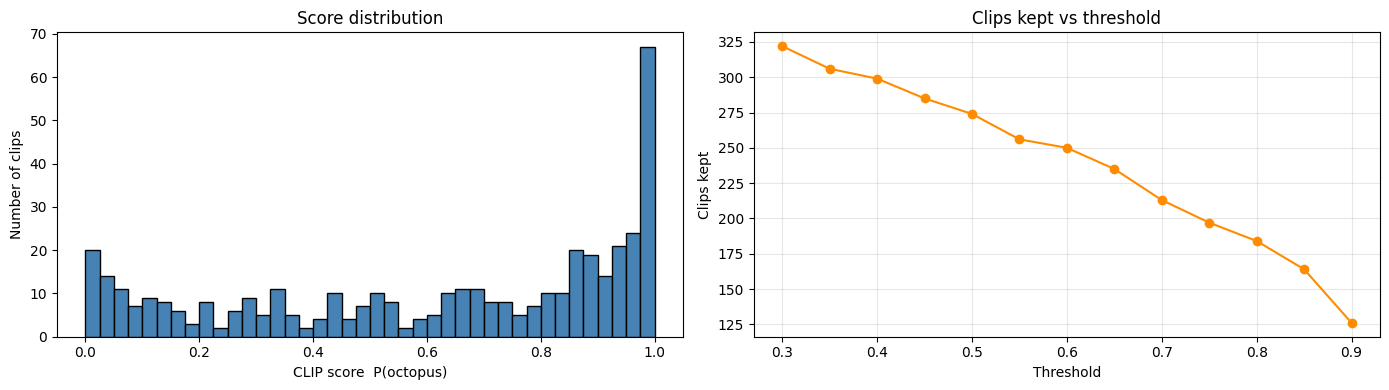

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(scores, bins=40, edgecolor="black", color="steelblue")
axes[0].set_xlabel("CLIP score  P(octopus)")
axes[0].set_ylabel("Number of clips")
axes[0].set_title("Score distribution")

thresholds = np.arange(0.3, 0.9, 0.05)
kept = [(scores >= t).sum() for t in thresholds]
axes[1].plot(thresholds, kept, marker="o", color="darkorange")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Clips kept")
axes[1].set_title("Clips kept vs threshold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Inspect clips at different score ranges
Adjust `THRESHOLD` based on the distribution above.

In [7]:
THRESHOLD = 0.6  # adjust after looking at the distribution

detected     = [(cid, s) for cid, s in zip(clip_ids, scores) if s >= THRESHOLD]
not_detected = [(cid, s) for cid, s in zip(clip_ids, scores) if s <  THRESHOLD]

print(f"Threshold : {THRESHOLD}")
print(f"Detected  : {len(detected)} clips")
print(f"Discarded : {len(not_detected)} clips")

Threshold : 0.6
Detected  : 250 clips
Discarded : 175 clips


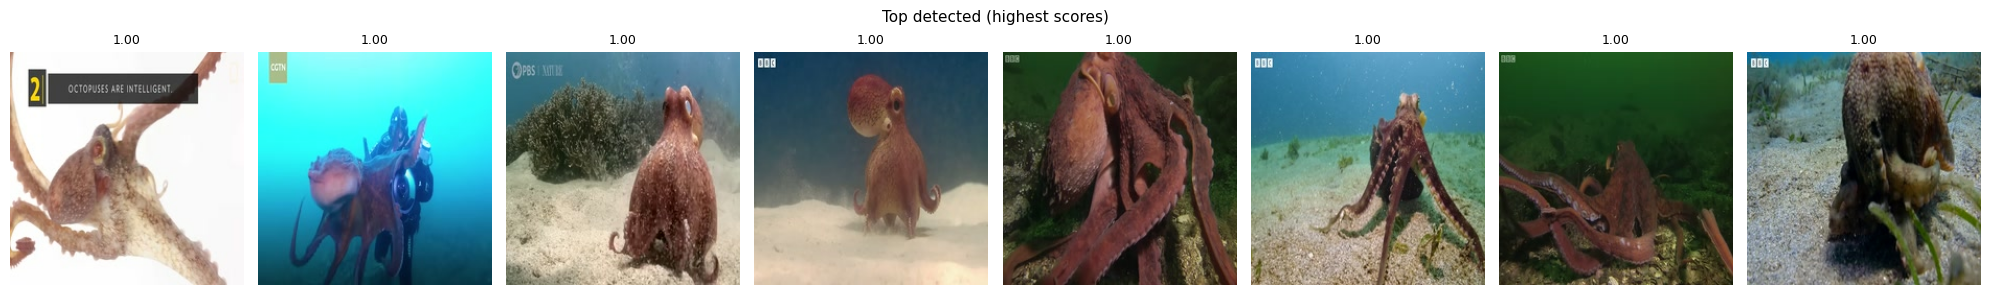

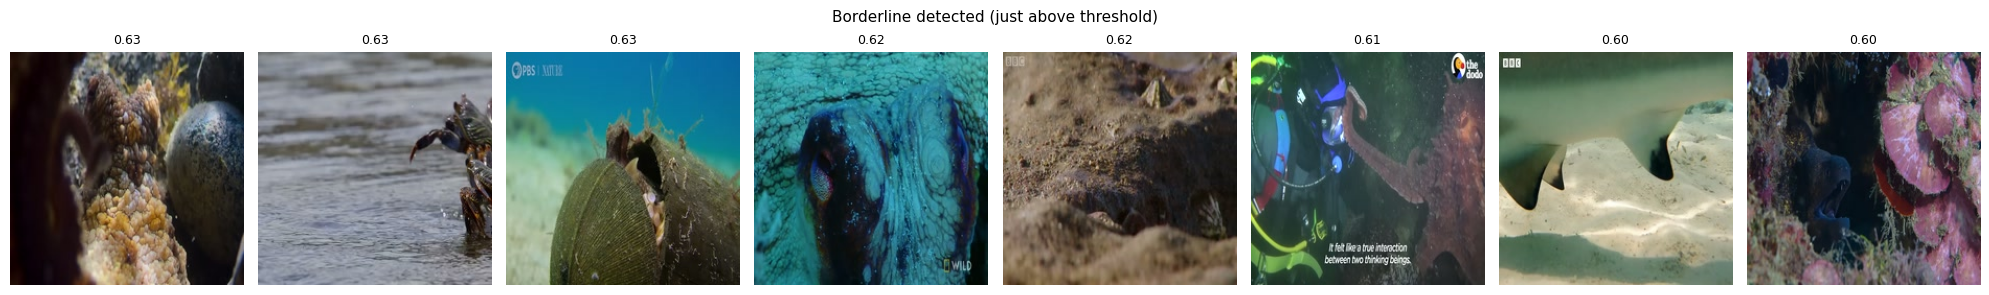

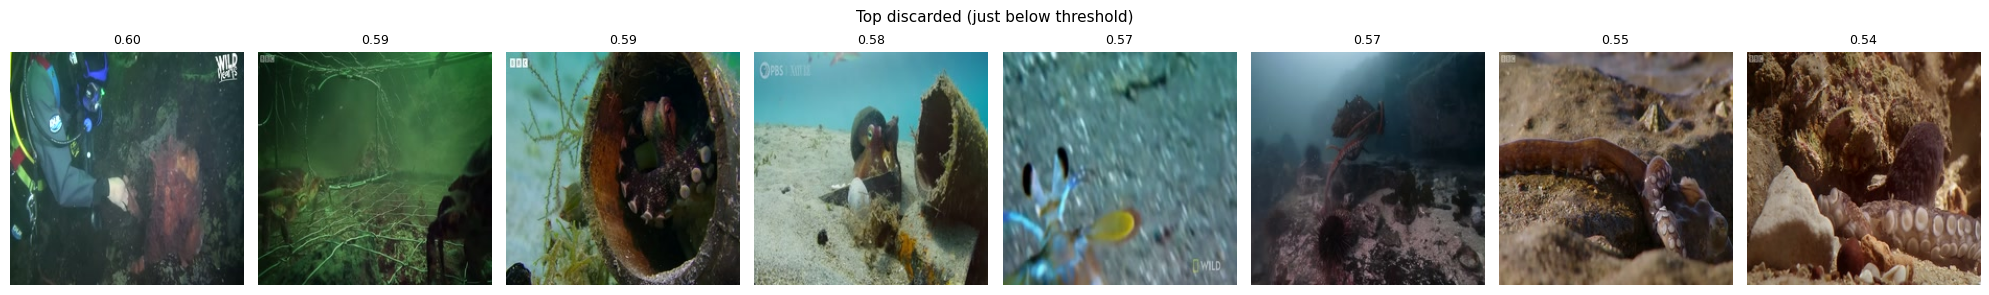

In [8]:
def show_clips(clip_score_list, title, n=8):
    """Show center frames for the first n clips."""
    sample = clip_score_list[:n]
    fig, axes = plt.subplots(1, len(sample), figsize=(2.5 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, (cid, s) in zip(axes, sample):
        frame = get_center_frame(CLIPS_DIR / cid)
        ax.imshow(mpimg.imread(str(frame)))
        ax.set_title(f"{s:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_clips(detected,     "Top detected (highest scores)")
show_clips(detected[-8:], "Borderline detected (just above threshold)")
show_clips(not_detected,  "Top discarded (just below threshold)")

## 6. Save results

In [9]:
out_path = Path("data/clip_scores.npz")
np.savez(
    out_path,
    clip_ids=np.array(clip_ids),
    scores=scores,
    threshold=np.float32(THRESHOLD),
)
print(f"Saved {len(clip_ids)} scores → {out_path}")
print(f"Detected clips at threshold {THRESHOLD}: {(scores >= THRESHOLD).sum()}")

Saved 425 scores → data/clip_scores.npz
Detected clips at threshold 0.6: 250
